<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/Gcgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

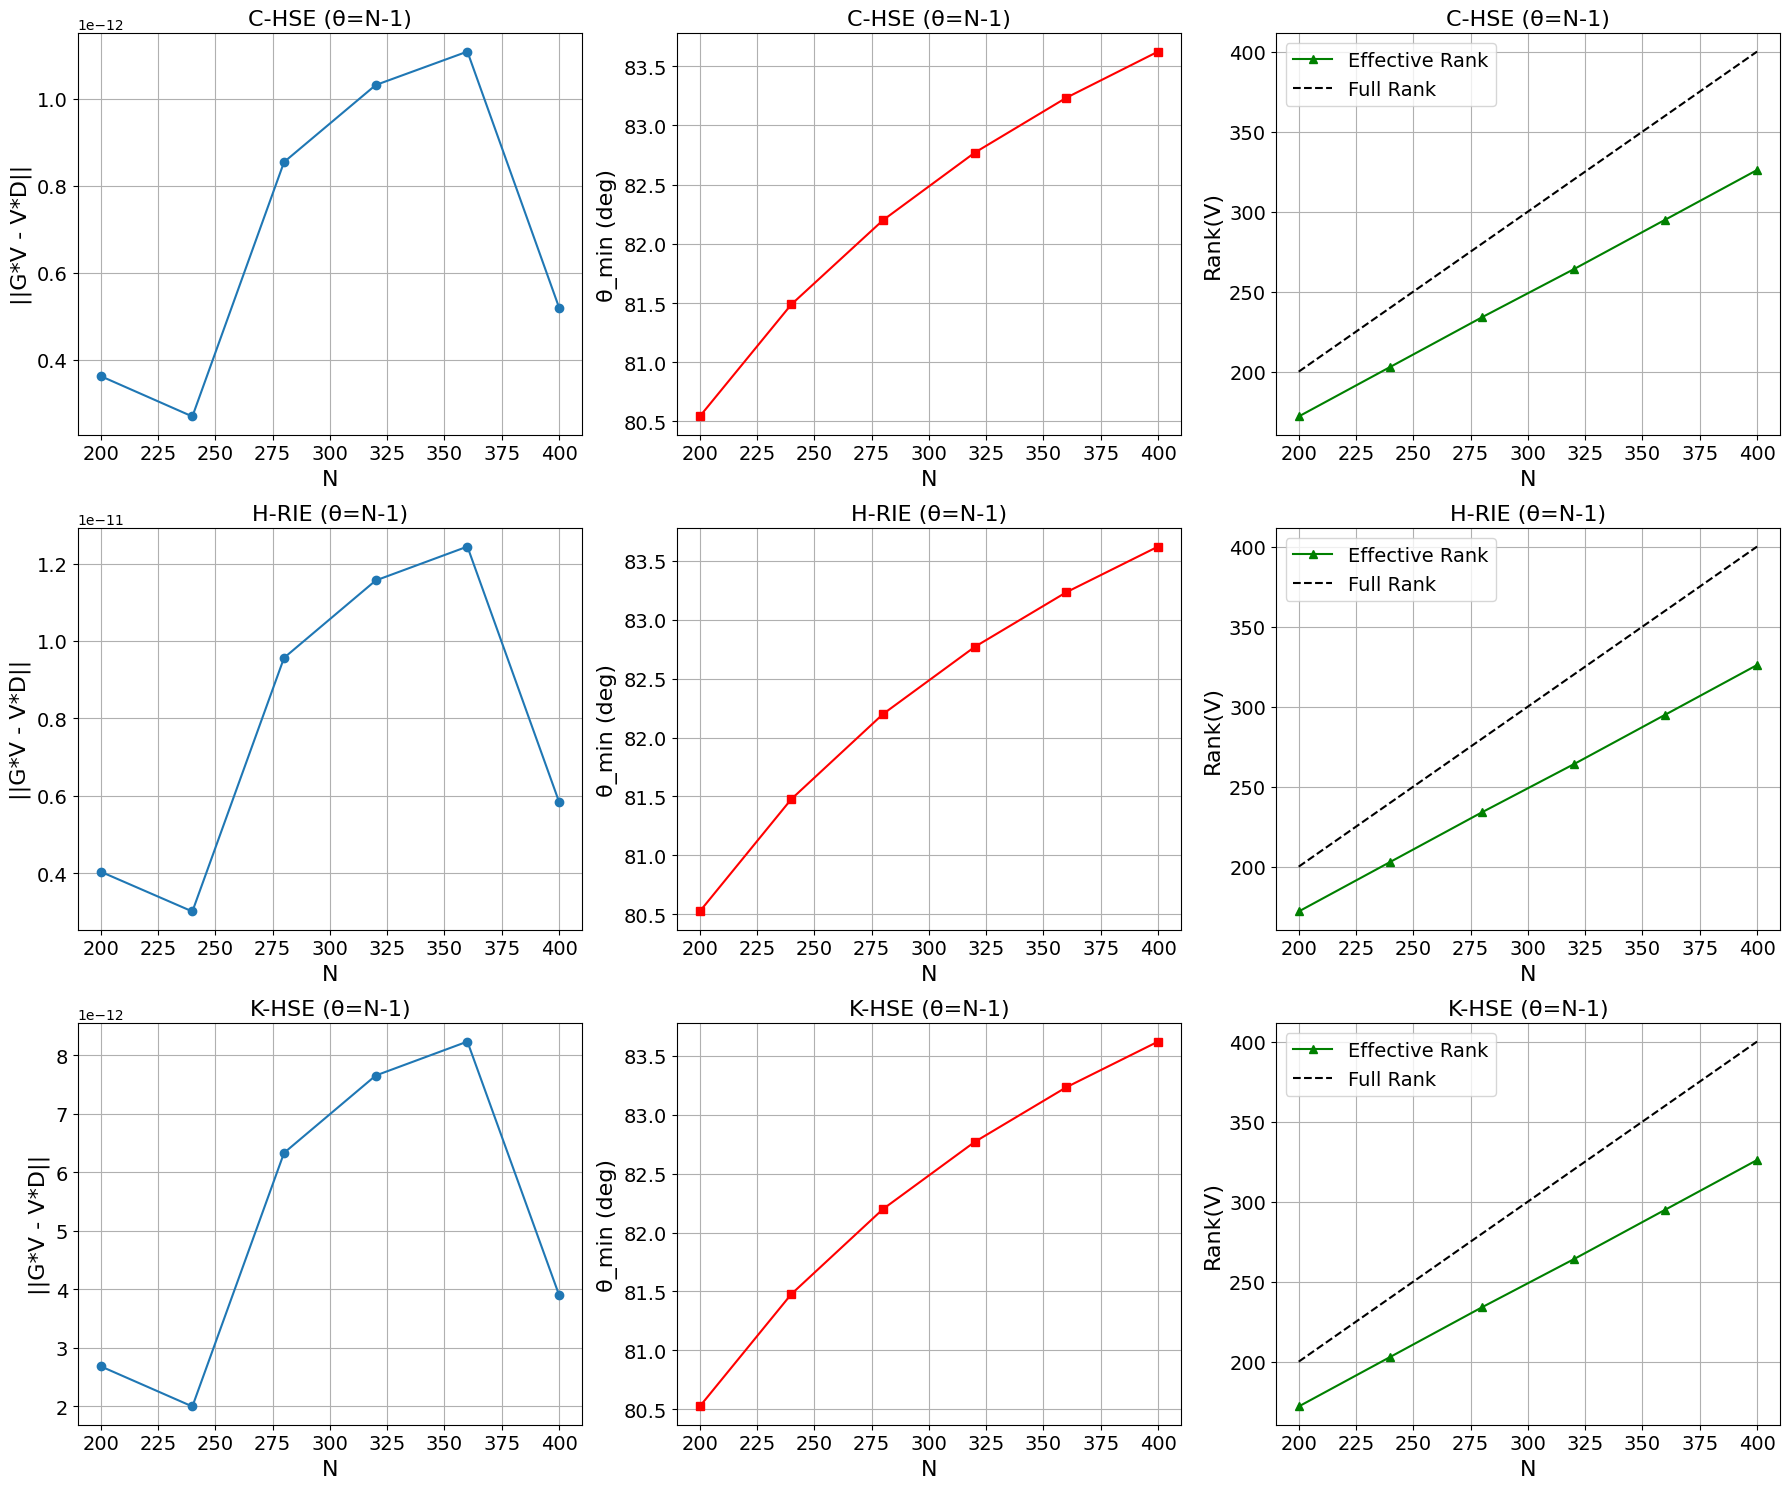

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All differences in all three codes are effectively zero (within numerical tolerance).


In [2]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from google.colab import files

# ----------------------------
# Utility functions
# ----------------------------
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

# ----------------------------
# m values
# ----------------------------
m_values = np.arange(50, 102, 10)

# ----------------------------
# Store results for three codes
# ----------------------------
diff_norm_vals_list = []
theta_min_vals_list = []
rank_vals_list = []

# ----------------------------
# -------- Code 1: Chebyshev Basis (θ=N-1) ------------
# ----------------------------
diff_norm_vals = []
theta_min_vals = []
rank_vals = []

for m in m_values:
    N = 4*m
    theta = N - 1

    w = np.exp(-2j * np.pi / N)
    k = np.arange(N).reshape(N, 1)
    l = np.arange(N).reshape(1, N)
    G = (1/np.sqrt(N)) * w**((k - theta/2.0) * (l - theta/2.0))

    C = np.real(G)
    S = np.imag(G)

    C2 = C @ C
    S2 = S @ S
    P_1  = 0.25*(C2 + C)
    P_m1 = 0.25*(C2 - C)
    P_i  = 0.25*(S2 + S)
    P_mi = 0.25*(S2 - S)

    X = P_1[:, m : 2*m]
    Y = P_m1[:, m : 2*m]
    Z = P_i[:, m : 2*m]
    T = P_mi[:, m : 2*m]

    diag_entries = np.hstack([np.ones(X.shape[1]),
                              -np.ones(Y.shape[1]),
                              1j*np.ones(Z.shape[1]),
                              -1j*np.ones(T.shape[1])])
    D = np.diag(diag_entries)

    V_G_c_cheby = np.hstack([X, Y, Z, T])

    diff1 = G @ V_G_c_cheby - V_G_c_cheby @ D
    diff_norm_vals.append(np.linalg.norm(diff1))

    Vn = normalize_columns(V_G_c_cheby)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    rank_vals.append(np.linalg.matrix_rank(V_G_c_cheby))

diff_norm_vals_list.append(diff_norm_vals)
theta_min_vals_list.append(theta_min_vals)
rank_vals_list.append(rank_vals)

# ----------------------------
# -------- Code 2: Real-Imag Eigenbasis (θ=N-1) ------------
# ----------------------------
diff_norm_vals = []
theta_min_vals = []
rank_vals = []

for m in m_values:
    N = 4*m
    theta = N - 1

    w = np.exp(-2 * np.pi * 1j / N)
    G = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            G[k, l] = (1 / np.sqrt(N)) * w**((k - theta/2) * (l - theta/2))

    I = np.eye(N)
    G_squared = G @ G
    P_theta = 0.5 * (I + G_squared)
    Q_theta = 0.5 * (I - G_squared)

    P = np.real(P_theta)
    Q = np.real(Q_theta)
    C = np.real(G)
    S = np.imag(G)

    Phi = np.vstack((P[0:2*m, :], Q[2*m:N, :]))
    Phi_inv = inv(Phi)

    result  = Phi @ C @ Phi_inv
    result1 = Phi @ S @ Phi_inv

    A = result[0:2*m, 0:2*m]
    B = result1[2*m:N, 2*m:N]

    X = A + np.eye(2*m)
    Y = A - np.eye(2*m)
    Z = B + np.eye(2*m)
    T = B - np.eye(2*m)

    X1 = X[:, 0:m]
    Y1 = Y[:, 0:m]
    Z1 = Z[:, 0:m]
    T1 = T[:, 0:m]

    X2 = np.vstack((X1, np.zeros((2*m, m))))
    Y2 = np.vstack((Y1, np.zeros((2*m, m))))
    Z2 = np.vstack((np.zeros((2*m, m)), Z1))
    T2 = np.vstack((np.zeros((2*m, m)), T1))

    X3 = Phi_inv @ X2
    Y3 = Phi_inv @ Y2
    Z3 = Phi_inv @ Z2
    T3 = Phi_inv @ T2

    V_G_c_reim = np.hstack((X3, Y3, Z3, T3))

    D_2 = np.zeros((N, N), dtype=complex)
    for k in range(m):
        D_2[k, k] = 1
        D_2[m+k, m+k] = -1
        D_2[2*m+k, 2*m+k] = 1j
        D_2[3*m+k, 3*m+k] = -1j

    diff1 = G @ V_G_c_reim - V_G_c_reim @ D_2
    diff_norm_vals.append(np.linalg.norm(diff1))

    Vn = normalize_columns(V_G_c_reim)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    rank_vals.append(np.linalg.matrix_rank(V_G_c_reim))

diff_norm_vals_list.append(diff_norm_vals)
theta_min_vals_list.append(theta_min_vals)
rank_vals_list.append(rank_vals)

# ----------------------------
# -------- Code 3: Kernel Matrix Basis (θ=N-1) ------------
# ----------------------------
diff_norm_vals = []
theta_min_vals = []
rank_vals = []

for m in m_values:
    N = 4*m
    w = np.exp(-2*np.pi*1j/N)
    t = N - 1

    C = np.array([[np.cos((k-(N-1)/2)*(l-(N-1)/2)*2*np.pi/N)/np.sqrt(N) for l in range(2*m)] for k in range(2*m)])
    S = np.array([[np.sin((k-(N-1)/2)*(l-(N-1)/2)*2*np.pi/N)/np.sqrt(N) for l in range(2*m)] for k in range(2*m)])

    I = np.eye(2*m)
    X = C + 0.5*I
    Y = C - 0.5*I
    Z = S + 0.5*I
    T = S - 0.5*I

    G = np.array([[w**((k - t/2)*(l - t/2))/np.sqrt(N) for l in range(N)] for k in range(N)], dtype=complex)

    J = np.flip(I, axis=0)

    X1 = X[:, :m]
    Y1 = Y[:, :m]
    Z1 = Z[:, :m]
    T1 = T[:, :m]

    X2 = np.vstack([X1, J @ X1])
    Y2 = np.vstack([Y1, J @ Y1])
    Z2 = np.vstack([Z1, -J @ Z1])
    T2 = np.vstack([T1, -J @ T1])

    V_G_c_kernelmatrix = np.hstack([X2, Y2, T2, Z2])

    D_3 = np.zeros((N, N), dtype=complex)
    for k in range(m):
        D_3[k, k] = 1
        D_3[m+k, m+k] = -1
        D_3[2*m+k, 2*m+k] = 1j
        D_3[3*m+k, 3*m+k] = -1j

    diff3 = G @ V_G_c_kernelmatrix - V_G_c_kernelmatrix @ D_3
    diff_norm_vals.append(np.linalg.norm(diff3))

    Vn = normalize_columns(V_G_c_kernelmatrix)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    rank_vals.append(np.linalg.matrix_rank(V_G_c_kernelmatrix))

diff_norm_vals_list.append(diff_norm_vals)
theta_min_vals_list.append(theta_min_vals)
rank_vals_list.append(rank_vals)

# ----------------------------
# Plot figures: 3 rows, 3 columns (Diff, Theta_min, Rank)
# ----------------------------
plt.figure(figsize=(18, 15))
font_size = 16

basis_names = [
    "C-HSE (θ=N-1)",
    "H-RIE (θ=N-1)",
    "K-HSE (θ=N-1)"
]
#Chebyshev Half-Shift Eigenbasis
#Half-Shift Real-Imag Eigenbasis
#Kernel Half-Shift Eigenbasis

for i in range(3):
    N_values = 4*m_values
    # Difference norm
    plt.subplot(3,3,i*3+1)
    plt.plot(N_values, diff_norm_vals_list[i], marker='o')
    plt.title(f"{basis_names[i]}", fontsize=font_size)
    plt.xlabel("N", fontsize=font_size)
    plt.ylabel("||G*V - V*D||", fontsize=font_size)
    plt.grid(True)
    plt.xticks(fontsize=font_size-2)
    plt.yticks(fontsize=font_size-2)

    # Theta_min
    plt.subplot(3,3,i*3+2)
    plt.plot(N_values, theta_min_vals_list[i], marker='s', color='red')
    plt.title(f"{basis_names[i]}", fontsize=font_size)
    plt.xlabel("N", fontsize=font_size)
    plt.ylabel("θ_min (deg)", fontsize=font_size)
    plt.grid(True)
    plt.xticks(fontsize=font_size-2)
    plt.yticks(fontsize=font_size-2)

    # Rank
    plt.subplot(3,3,i*3+3)
    plt.plot(N_values, rank_vals_list[i], marker='^', color='green', label='Effective Rank')
    plt.plot(N_values, N_values, '--k', label='Full Rank')
    plt.title(f"{basis_names[i]}", fontsize=font_size)
    plt.xlabel("N", fontsize=font_size)
    plt.ylabel("Rank(V)", fontsize=font_size)
    plt.legend(fontsize=font_size-2)
    plt.grid(True)
    plt.xticks(fontsize=font_size-2)
    plt.yticks(fontsize=font_size-2)

plt.tight_layout()

# ----------------------------
# Save figure as PDF and PNG
# ----------------------------
plt.savefig("basis_analysis.pdf", format='pdf', bbox_inches='tight')
plt.savefig("basis_analysis.png", format='png', dpi=300, bbox_inches='tight')

plt.show()

# ----------------------------
# Download files in Colab
# ----------------------------
files.download("basis_analysis.pdf")
files.download("basis_analysis.png")

print("All differences in all three codes are effectively zero (within numerical tolerance).")
